In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/products-with-captions/products_with_captions.csv


In [18]:
# Install & Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Set pandas options for wider output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [7]:
# Load the Dataset

# Adjust path if necessary for your uploaded file
csv_path = "/kaggle/input/products-with-captions/products_with_captions.csv"
df = pd.read_csv(csv_path)

df.info()
df.describe(include='all')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61530 entries, 0 to 61529
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   item_id              61530 non-null  object
 1   image_id             61530 non-null  object
 2   item_name            61530 non-null  object
 3   brand                57518 non-null  object
 4   bullet_point         52887 non-null  object
 5   item_keywords        47310 non-null  object
 6   material             20290 non-null  object
 7   node_name            55594 non-null  object
 8   color_standardized   26483 non-null  object
 9   product_type         61530 non-null  object
 10  model_name           15548 non-null  object
 11  style                23297 non-null  object
 12  fabric_type          4993 non-null   object
 13  pattern              2910 non-null   object
 14  item_shape           3936 non-null   object
 15  finish_type          1354 non-null   object
 16  prod

,item_id,image_id,item_name,brand,bullet_point,item_keywords,material,node_name,color_standardized,product_type,model_name,style,fabric_type,pattern,item_shape,finish_type,product_description,image_caption,image_path
0,B07T7ZY6P6,71bcNwxkB7L,Amazon Brand - Solimo Designer Lighting 3D Pri...,Amazon Brand - Solimo,3D Printed Hard Back Case Mobile Cover for Viv...,mobile cover | back cover | mobile case | phon...,NaN,/Categories/Mobiles & Accessories/Mobile Acces...,multi-colored,CELLULAR_PHONE_CASE,Vivo V1 Max,NaN,NaN,NaN,NaN,NaN,NaN,a phone case with christmas lights on it,/c3/c3406c06.jpg
1,B07YQPTXFK,71I4ezaoNgL,"Amazon Meal Kits, Chicken & Vegetable Stir-Fry...",Amazon Meal Kits,Ginger chicken stir-fried with vegetables serv...,dinner | dinners | dinner kit | easy dinner | ...,NaN,/Categories/Fresh Meal Kits,NaN,GROCERY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a box of chicken and vegetable pasta on a whit...,/10/102157fb.jpg
2,B0853X5SQ5,616ZijT0A5L,Amazon Brand - Solimo Designer Red Moon UV Pri...,Amazon Brand - Solimo,"Snug fit for Lava Z61, with perfect cut-outs f...",Back Cover | Designer Case | Designer Red Moon...,Silicon,/Categories/Mobiles & Accessories/Mobile Acces...,multi-colored,CELLULAR_PHONE_CASE,Lava Z61,NaN,NaN,NaN,NaN,NaN,NaN,a phone case with the silhouette of a red moon...,/a7/a7270e7a.jpg
3,B07PPXFC2R,51rXStEHElL,Amazon Essentials Belice Women's Flat Ballet F...,NaN,Classic and versatile ballet flats for everyda...,NaN,NaN,/Kategorien/Schuhe/Damen/Flache Schuhe/Ballerinas,NaN,SHOES,Belice Women's Ballet Flat,NaN,100% Synthetic,NaN,NaN,NaN,NaN,a pair of leopard print shoes,/55/55c7d8e2.jpg
4,B07VTCS9DQ,71byIpH+1LL,Amazon Brand - Solimo Deep Moisturizing Baby W...,Solimo,One 13-fluid ounce bottle of deep moisturizing...,baby wash | baby body wash | bath wash for bab...,NaN,NaN,NaN,SKIN_CLEANING_AGENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a bottle of soap on a white background,/87/87868d71.jpg


In [8]:
# Field Summary Statistics

# Function to calculate word count
def word_count(text):
    if pd.isnull(text):
        return 0
    return len(str(text).split())

summary = []
for col in df.columns:
    non_null_count = df[col].notnull().sum()
    missing_percentage = round(100 * (1 - non_null_count / len(df)), 2)
    word_counts = df[col].dropna().astype(str).apply(word_count)

    summary.append({
        "Variable": col,
        "Non-Null Count": non_null_count,
        "Missing (%)": missing_percentage,
        "Mean Word Count": round(word_counts.mean(), 2),
        "Median Word Count": word_counts.median(),
        "Max Word Count": word_counts.max()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Variable,Non-Null Count,Missing (%),Mean Word Count,Median Word Count,Max Word Count
0,item_id,61530,0.00,1.00,1.0,1
1,image_id,61530,0.00,1.00,1.0,1
2,item_name,61530,0.00,12.46,12.0,61
3,brand,57518,6.52,2.31,2.0,11
4,bullet_point,52887,14.05,66.80,68.0,606
5,item_keywords,47310,23.11,118.39,77.0,256
6,material,20290,67.02,1.41,1.0,23
7,node_name,55594,9.65,4.99,5.0,19
8,color_standardized,26483,56.96,1.00,1.0,8
9,product_type,61530,0.00,1.00,1.0,1


In [9]:
# Top 20 Product Types

top_product_types = (
    df['product_type']
    .value_counts()
    .head(20)
    .reset_index()
)
top_product_types.columns = ['product_type', 'count']
top_product_types['percentage'] = round((top_product_types['count'] / len(df)) * 100, 2)

top_product_types

,product_type,count,percentage
0,CELLULAR_PHONE_CASE,6977,11.34
1,SHOES,6977,11.34
2,GROCERY,6177,10.04
3,HOME,2638,4.29
4,CHAIR,1713,2.78
5,HOME_BED_AND_BATH,1662,2.70
6,HOME_FURNITURE_AND_DECOR,1376,2.24
7,HEALTH_PERSONAL_CARE,1168,1.90
8,BOOT,1161,1.89
9,SANDAL,1015,1.65


In [10]:
# Duplicate Analysis (IDs and Paths)

cols_to_check = ['item_id', 'image_id', 'image_path']
duplicate_summary = []

for col in cols_to_check:
    total = len(df)
    unique = df[col].nunique()
    duplicate_count = total - unique
    duplicate_rows = df[df.duplicated(subset=[col], keep=False)]

    duplicate_summary.append({
        "Column": col,
        "Total Entries": total,
        "Unique Values": unique,
        "Duplicate Count": duplicate_count,
        "Duplicate %": round(duplicate_count / total * 100, 2),
        "Max Duplicates for Single Value": duplicate_rows[col].value_counts().max()
    })

pd.DataFrame(duplicate_summary)

,Column,Total Entries,Unique Values,Duplicate Count,Duplicate %,Max Duplicates for Single Value
0,item_id,61530,60937,593,0.96,3
1,image_id,61530,50030,11500,18.69,435
2,image_path,61530,50030,11500,18.69,435


In [11]:
# Top 30 Duplicate Image Paths

duplicate_image_paths = (
    df['image_path']
    .value_counts()
    .loc[lambda x: x > 1]
    .head(30)
    .reset_index()
)
duplicate_image_paths.columns = ['image_path', 'count']
duplicate_image_paths

,image_path,count
0,/35/3595924e.jpg,435
1,/b5/b5319e00.jpg,156
2,/87/87c11ce5.jpg,118
3,/86/86d56c14.jpg,99
4,/87/874f86c4.jpg,81
5,/b1/b1b4cf34.jpg,56
6,/bd/bdd01c80.jpg,28
7,/48/48d9d8ae.jpg,22
8,/20/20533b83.jpg,22
9,/99/99d1504e.jpg,20


In [12]:
# Clean Stock Images & Duplicates

stock_image_paths = [
    "/35/3595924e.jpg", "/b5/b5319e00.jpg", "/87/87c11ce5.jpg", "/86/86d56c14.jpg",
    "/87/874f86c4.jpg", "/b1/b1b4cf34.jpg", "/bd/bdd01c80.jpg", "/48/48d9d8ae.jpg",
    "/20/20533b83.jpg", "/99/99d1504e.jpg"
]

df_cleaned = df[~df['image_path'].isin(stock_image_paths)]
df_cleaned = df_cleaned.drop_duplicates(subset='item_id', keep='first')
df_cleaned.reset_index(drop=True, inplace=True)
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Cleaned dataset shape: (59908, 19)


In [14]:
# Cleaned Field Summary + Duplicates

# Field summary
summary_stats = []
for col in df_cleaned.columns:
    non_null_count = df_cleaned[col].notnull().sum()
    missing_pct = round(100 * (1 - non_null_count / len(df_cleaned)), 2)
    word_counts = df_cleaned[col].dropna().astype(str).apply(word_count)

    summary_stats.append({
        "Variable": col,
        "Non-Null Count": non_null_count,
        "Missing (%)": missing_pct,
        "Mean Word Count": round(word_counts.mean(), 2),
        "Median Word Count": word_counts.median(),
        "Max Word Count": word_counts.max()
    })

field_summary_df = pd.DataFrame(summary_stats)

# Duplicate check
duplicate_stats = []
for col in ['item_id', 'image_id', 'image_path']:
    total = len(df_cleaned)
    unique = df_cleaned[col].nunique()
    dup_count = total - unique
    max_dupes = df_cleaned[df_cleaned.duplicated(subset=[col], keep=False)][col].value_counts().max()

    duplicate_stats.append({
        "Column": col,
        "Total Entries": total,
        "Unique Values": unique,
        "Duplicate Count": dup_count,
        "Duplicate %": round((dup_count / total) * 100, 2),
        "Max Duplicates for Single Value": max_dupes
    })

duplicate_summary_df = pd.DataFrame(duplicate_stats)

In [15]:
print("📋 Field Summary")
display(field_summary_df)

📋 Field Summary


,Variable,Non-Null Count,Missing (%),Mean Word Count,Median Word Count,Max Word Count
0,item_id,59908,0.00,1.00,1.0,1
1,image_id,59908,0.00,1.00,1.0,1
2,item_name,59908,0.00,12.52,12.0,61
3,brand,55941,6.62,2.34,2.0,11
4,bullet_point,51926,13.32,66.81,69.0,606
5,item_keywords,46542,22.31,119.50,79.0,256
6,material,20079,66.48,1.42,1.0,23
7,node_name,54218,9.50,5.01,5.0,19
8,color_standardized,26104,56.43,1.00,1.0,8
9,product_type,59908,0.00,1.00,1.0,1


In [19]:
print("\n🔁 Duplicate Summary")
display(duplicate_summary_df)


🔁 Duplicate Summary


,Column,Total Entries,Unique Values,Duplicate Count,Duplicate %,Max Duplicates for Single Value
0,item_id,59908,59908,0,0.00,NaN
1,image_id,59908,49801,10107,16.87,19.0
2,image_path,59908,49801,10107,16.87,19.0


In [20]:
# --- Top 20 Product Types ---
top_20_product_types = (
    df_cleaned['product_type']
    .value_counts()
    .head(20)
    .reset_index()
)

top_20_product_types.columns = ['product_type', 'count']

top_20_product_types['percentage'] = round(
    (top_20_product_types['count'].astype(int) / len(df_cleaned)) * 100, 2
)

top_20_product_types


,product_type,count,percentage
0,CELLULAR_PHONE_CASE,6977,11.65
1,SHOES,6820,11.38
2,GROCERY,5895,9.84
3,HOME,2453,4.09
4,CHAIR,1665,2.78
5,HOME_BED_AND_BATH,1605,2.68
6,HOME_FURNITURE_AND_DECOR,1349,2.25
7,HEALTH_PERSONAL_CARE,1153,1.92
8,BOOT,1108,1.85
9,SOFA,994,1.66


In [21]:
# Reorder Columns

id_columns = ['item_id', 'image_id', 'image_path']
embedding_priority_columns = [
    'item_name', 'product_type', 'bullet_point', 'product_description', 'image_caption',
    'brand', 'model_name', 'node_name', 'color_standardized', 'style', 'material',
    'fabric_type', 'pattern', 'item_shape', 'finish_type', 'item_keywords'
]

ordered_columns = id_columns + embedding_priority_columns
df_cleaned = df_cleaned[ordered_columns]

df_cleaned.columns

Index(['item_id', 'image_id', 'image_path', 'item_name', 'product_type', 'bullet_point', 'product_description', 'image_caption', 'brand', 'model_name', 'node_name', 'color_standardized', 'style', 'material', 'fabric_type', 'pattern', 'item_shape', 'finish_type', 'item_keywords'], dtype='object')

In [22]:
# Duplicate Captions & Save CSV

duplicate_image_captions = (
    df_cleaned['image_caption']
    .value_counts()
    .loc[lambda x: x > 1]
    .reset_index()
)
duplicate_image_captions.columns = ['image_caption', 'count']
duplicate_image_captions.head(20)

,image_caption,count
0,[undetermined product],4445
1,a pair of black shoes on a white background,172
2,a pair of women ' s shoes on a white background,171
3,an image of a bed with a headboard and foot board,133
4,a phone case with a painting on it,114
5,a picture of a brown derby shoe,113
6,a phone case with a colorful painting on it,111
7,a pair of diamond stud earrings,108
8,a pair of black sandals on a white background,105
9,a pair of black leather ankle boots,104


In [23]:
# Save Cleaned Data 

df_cleaned.to_csv("/kaggle/working/cleaned_products_with_captions.csv", index=False)
print("File saved to working directory!")

File saved to working directory!


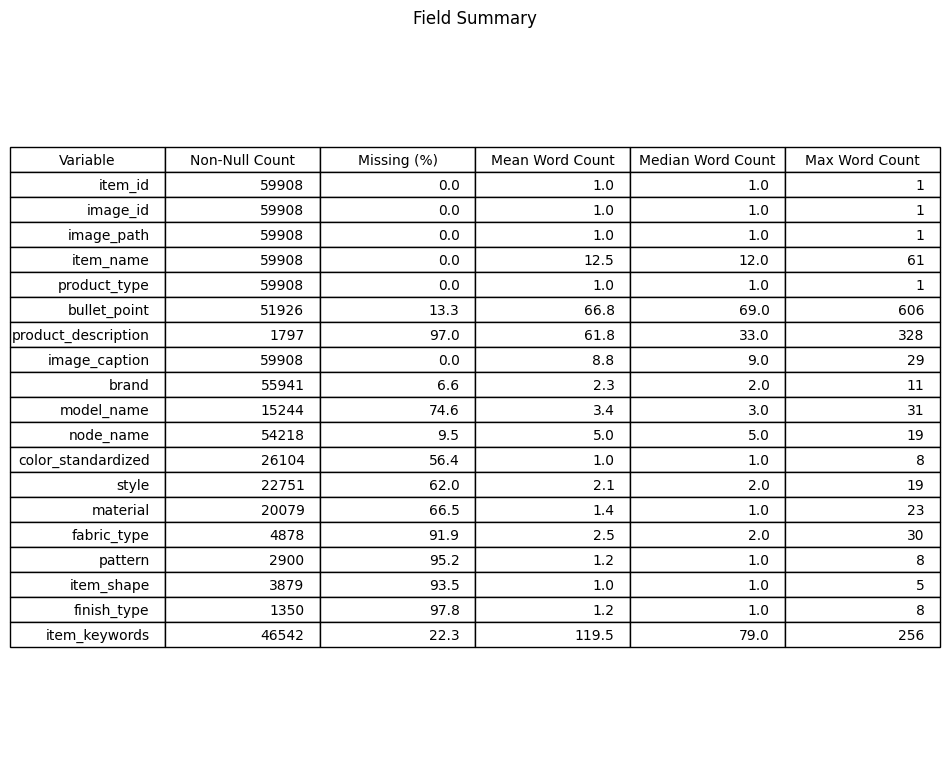

In [24]:
# Field Summary Table as a Matplotlib Table

# Round numerical values to 1 decimal
field_summary_df = field_summary_df.round(1)

# Ensure column order follows cleaned dataset
field_summary_df["Variable"] = pd.Categorical(
    field_summary_df["Variable"],
    categories=df_cleaned.columns,
    ordered=True
)
field_summary_df = field_summary_df.sort_values("Variable")

# Create table-style plot using matplotlib
fig, ax = plt.subplots(figsize=(12, len(field_summary_df) * 0.5))
ax.axis('off')
table = ax.table(
    cellText=field_summary_df.values,
    colLabels=field_summary_df.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Field Summary")
plt.savefig("/kaggle/working/field_summary_table.png", bbox_inches='tight')
plt.show()

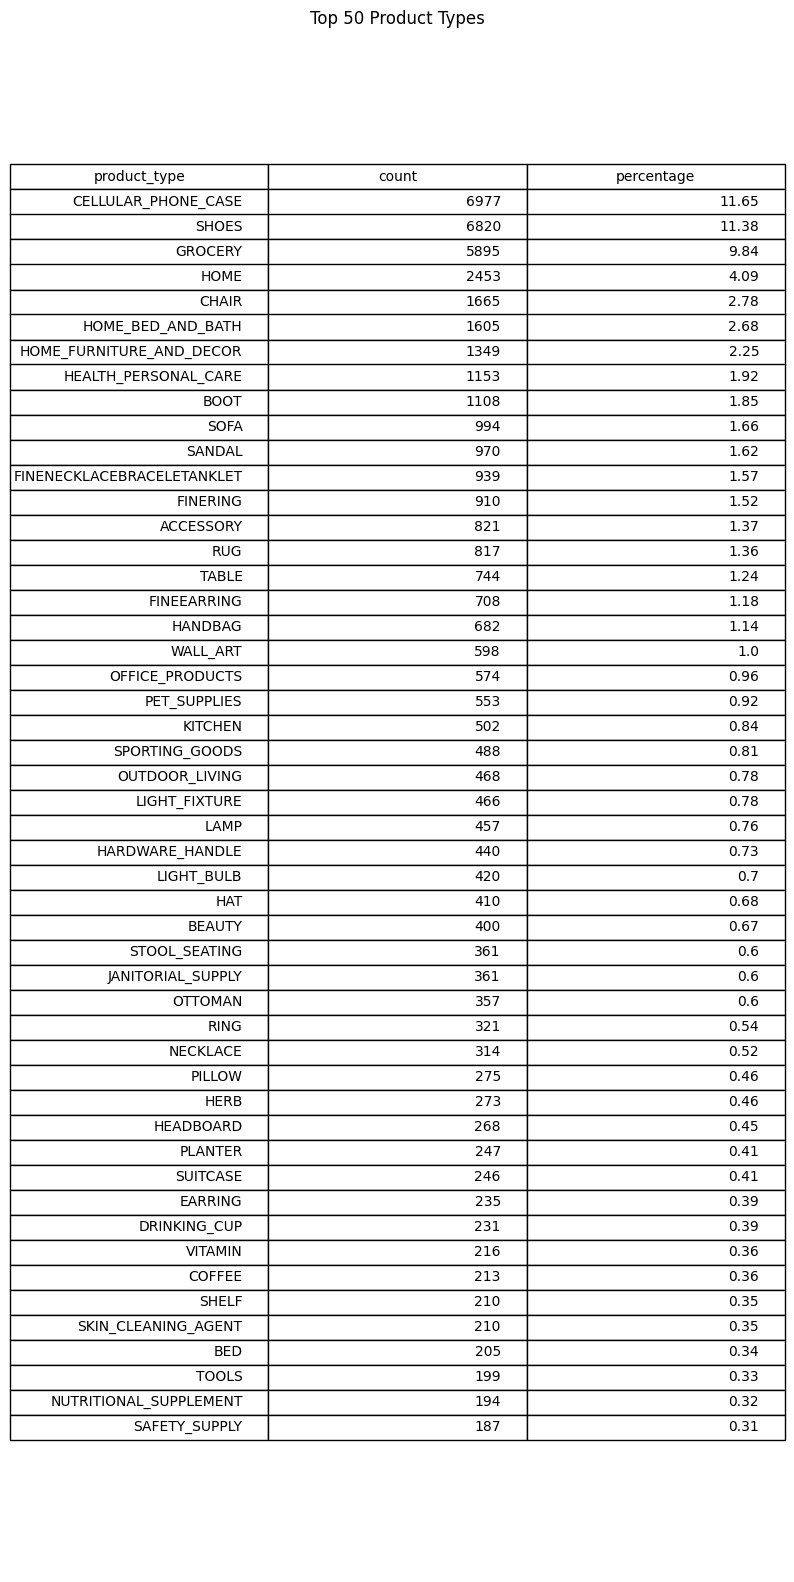

In [27]:
# Top 50 Product Types – Table View

top_50_product_types = (
    df_cleaned['product_type']
    .value_counts()
    .head(50)
    .reset_index()
)
top_50_product_types.columns = ['product_type', 'count']
top_50_product_types['percentage'] = round(
    top_50_product_types['count'] / len(df_cleaned) * 100, 2
)

# Table-style plot
top_50_product_types = top_50_product_types.round(2)
fig, ax = plt.subplots(figsize=(10, len(top_50_product_types) * 0.4))
ax.axis('off')
table = ax.table(
    cellText=top_50_product_types.values,
    colLabels=top_50_product_types.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Top 50 Product Types")
plt.savefig("/kaggle/working/top_50_product_types_table.png", bbox_inches='tight')
plt.show()